# Example of how to run the v7.0 CLASS implementation of Cold New Early Dark Energy

In [3]:
import matplotlib.pyplot as plt
import numpy as np
from time import perf_counter
from scipy.interpolate import interp1d
def interp_onto(xdata, ydata, new_xdata):
    return interp1d(xdata, ydata, fill_value="extrapolate")(new_xdata)
def get_spectrum(class_instance, lensing=True):
    if lensing:
        cls  = class_instance.lensed_cl(2500)
    else:
        cls  = class_instance.raw_cl(2500)
    ll   = cls['ell'][2:]
    clTT = cls['tt'][2:]
    cl   = clTT*ll*(ll+1)/2./np.pi
    return ll, cl

from classy import Class

#### $\Lambda$ CDM run to compare with

In [4]:
k_max    = 1.0
kk = np.logspace(-4,np.log10(k_max),1000) # k in h/Mpc
k_plot = 0.2

LCDM_settings = {
    'output'           : 'tCl, lCl, mPk',
    'lensing'          : 'yes',
    'P_k_max_1/Mpc'    : k_max,
    'k_output_values'  : k_plot,
    'omega_b'          : 0.02238280,
    'omega_cdm'        : 0.1201075,
    'tau_reio'         : 0.05430842,
    'n_s'              : 0.9660499,
    'A_s'              : 2.100549e-09,
    'h'                : 0.67,
    'N_eff'            : 2.038,
    'YHe'              : 0.2454006,
    'N_ncdm': 1,
    'm_ncdm': 0.06,
}
LCDM = Class()
LCDM.set(LCDM_settings)
LCDM.compute()
ll_lcdm, cl_lcdm = get_spectrum(LCDM)
pk_lcdm = np.array([k**(3/2)*LCDM.pk(k*LCDM.h(), 0.)*LCDM.h()**3 for k in kk])

In [5]:
NEDE_settings = {
    'f_NEDE': 0.23612917, 
    'z_decay_NEDE': 10**3.6134105, 
    'three_eos_NEDE': 1.959447, 
    'Junction_tag': 1,
    'H_over_m_NEDE': 0.2,
    'Omega0_NEDE_trigger_DM': 0.3,
    'NEDE_trigger_fluid_H_m': 0.01,
    'NEDE_ceff_nature': 'tracking',
    'sub_dom_cond':1e-6,
    'start_small_k_at_tau_c_over_tau_h':0.0000001
}

# These are the recommended precision settings, for which v7.0 has been verified to match older versions
precision_settings = {
    # No longer uses these old settings from TriggerCLASS versions < 7.0!
    # 'decay_res_enhancement': 100,
    # 'trigger_resolution': 0.005,

    'tol_background_integration': 1e-10, # default
    'background_integration_stepsize': 1e-3, # ignored when using ndf15

    'tol_perturbations_integration': 1.0e-8,
    'perturbations_integration_stepsize': 0.5,
    'perturbations_sampling_stepsize': 0.003,

    'tol_shooting_deltax_rel': 1e-8,
    'tol_shooting_deltax': 1e-8,
    'tol_shooting_deltaF': 1e-8,
    
    'background_evolver': 1, # ndf15 for background, alternatively, use 2 for rkdp45
    'evolver': 1, 
    'plot_gauge': 'synchronous' # species which gauge to plot quantities in (WARNING: Not tested for Newtonian gauge)
}

In [6]:
v7 = Class()
v7.set(LCDM_settings | NEDE_settings | precision_settings)
tic = perf_counter()
v7.compute()
toc = perf_counter()
print(f"Ran version 7.0 w. perts in {toc - tic:.3} s")

Ran version 7.0 w. perts in 50.9 s


# 1: CMB Plot

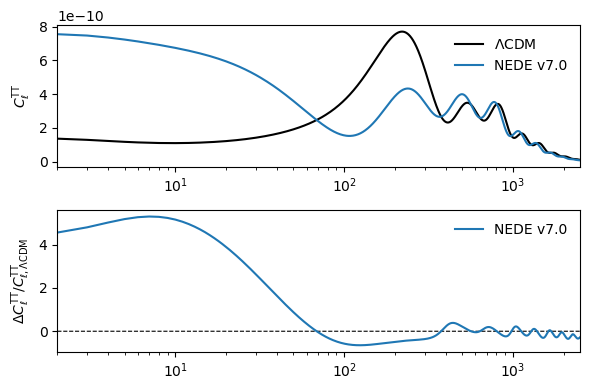

In [9]:
ll_v7, cl_v7 = get_spectrum(v7)

fig, ax = plt.subplots(2,1, figsize=[6, 4])
ax[0].set_xscale('log')
ax[0].set_yscale('linear')
ax[0].set_xlim(2,2500)
ax[0].set_ylabel(r'$C_\ell^{\mathrm{TT}}$')
ax[0].plot(ll_lcdm, cl_lcdm, 'k-', label=r'$\Lambda$CDM')
ax[0].plot(ll_v7, cl_v7, '-', label=f"NEDE v7.0")
ax[0].legend(frameon=False)
ax[1].set_ylabel(r'$\Delta C_{\ell}^{\mathrm{TT}}/C_{\ell,\Lambda\mathrm{CDM}}^{\mathrm{TT}}$')
ax[1].set_xscale('log')
ax[1].set_yscale('linear')
ax[1].set_xlim(2,2500)
ax[1].plot(ll_lcdm, np.zeros(len(ll_lcdm)), 'k--', lw=0.8)
ax[1].plot(ll_v7, (cl_v7 - cl_lcdm)/cl_lcdm, '-', label=f"NEDE v7.0")
ax[1].legend(frameon=False)
fig.tight_layout()


Crazy spectrum, but that's due to the chosen NEDE parameters.

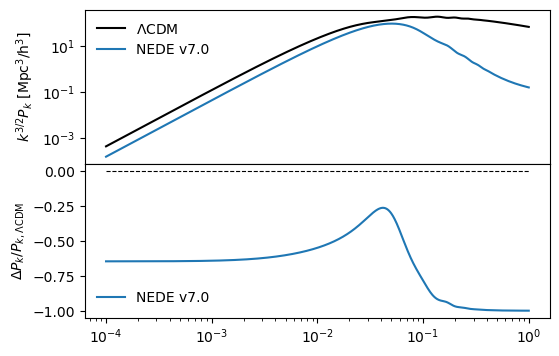

In [11]:
pk_v7 = np.array([k**(3/2)*v7.pk(k*v7.h(), 0.)*v7.h()**3 for k in kk])

fig, ax = plt.subplots(2,1, figsize=[6, 4])
ax[0].set_xscale('log')
ax[0].set_yscale('log')
ax[0].set_ylabel(r'$k^{3/2} P_k$ [Mpc$^3$/h$^3$]')
ax[0].plot(kk, pk_lcdm, 'k-', label=r'$\Lambda$CDM')
ax[0].plot(kk, pk_v7, '-', label=f"NEDE v7.0")
ax[0].legend(frameon=False)
ax[1].set_ylabel(r'$\Delta P_k/P_{k,\Lambda\mathrm{CDM}}$')
ax[1].set_xscale('log')
ax[1].set_yscale('linear')
ax[1].plot(kk, (pk_v7 - pk_lcdm)/pk_lcdm, '-', label=f"NEDE v7.0")
ax[1].plot(kk, np.zeros(len(kk)), 'k--', lw=0.8)
ax[1].legend(frameon=False)
fig.subplots_adjust(hspace=0.)

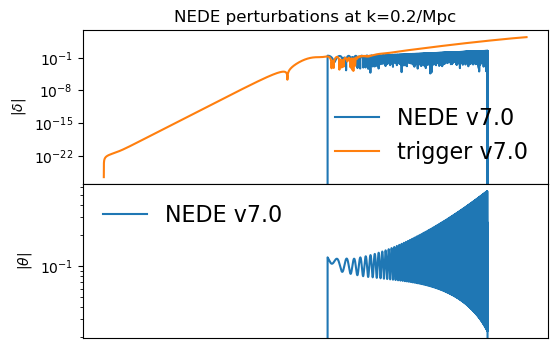

In [14]:
pt_v7 = v7.get_perturbations()['scalar'][0]
fig, ax = plt.subplots(2,1, figsize=[6, 4])
ax[0].set_title(f'NEDE perturbations at k={k_plot}/Mpc')
ax[0].set(xscale='log', yscale='log', xticks=[], ylabel=r'$|\delta|$')
ax[0].plot(pt_v7['a'], np.abs(pt_v7['delta_NEDE']), '-', label=f"NEDE v7.0")
ax[1].plot(pt_v7['a'], np.abs(pt_v7['theta_NEDE']), '-', label=f"NEDE v7.0")
ax[0].plot(pt_v7['a'], np.abs(pt_v7['delta_trigger']), '-', label=f"trigger v7.0")
ax[0].legend(frameon=False, fontsize=16)
ax[1].set(xscale='log', yscale='log', xticks=[], ylabel=r'$|\theta|$')
ax[1].legend(frameon=False, fontsize=16)
fig.subplots_adjust(hspace=0.)